[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/03_single_variable_derivatives/first_principles.ipynb)

# Module 03 — Single Variable Derivatives

## 1. Why This Module Exists

Every quantitative model answers the same question: if I nudge the input, what happens to the output? A model that cannot answer it cannot be optimised, calibrated, or trusted near its operating point.

The derivative is the answer in its sharpest form. It replaces a nonlinear function, locally, by the single linear map that reproduces its response to first order. That replacement is what makes gradient descent, Newton's method, sensitivity analysis, kinematics, and backpropagation possible: all of them run on local linear models and none of them ever look at the whole function at once.

This module builds the derivative from the limit of secant slopes in [`calculus/02_limits_and_continuity`](../02_limits_and_continuity/), proves the differentiation rules rather than reciting them, and finishes with the two ways a machine actually computes derivatives — finite differences, which trade truncation error against round-off, and forward-mode automatic differentiation, which has no truncation error at all.

The rule that carries the most weight downstream is the chain rule. Backpropagation is the chain rule applied to a composition of a few hundred functions; the proof in Section 5 is the one that must be airtight, and the popular "cancel the $du$" argument is not.

## 2. Intuition

Fix a point $x$ and a nonzero increment $h$. Over the interval between $x$ and $x + h$ the function's *average* rate of change is the slope of the secant line through $(x, f(x))$ and $(x+h, f(x+h))$:

$$
\frac{\Delta y}{\Delta x} = \frac{f(x+h) - f(x)}{h}
$$

Shrink $h$. The second point slides along the curve toward the first, and the secant line pivots about $(x, f(x))$. If the pivoting settles on one limiting line, that line is the **tangent**, and its slope is the *instantaneous* rate of change.

There is a second, equivalent picture that generalises far better. Ask: among all straight lines through $(x, f(x))$, which one approximates $f$ best near $x$? Writing a candidate as $f(x) + Lh$, the approximation error is

$$
E(h) = f(x+h) - f(x) - Lh
$$

Every line with the wrong slope leaves an error proportional to $h$. Exactly one choice of $L$ makes the error vanish *faster* than $h$, and that $L$ is the derivative. So the derivative is not merely "a slope"; it is the unique first-order linear model of $f$ at $x$, and the whole of differential calculus is the bookkeeping that keeps such models consistent under sums, products, and composition.

Below, the secant slopes for $f(x) = x^2$ at $x = 1$ are drawn for shrinking $h$; they converge on the tangent of slope $2$.

Standard preamble, used by every code cell in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

**Figure 1 (Section 2).** Secant lines through $(1, 1)$ and $(1+h, (1+h)^2)$ for $h = 1.0, 0.5, 0.25$,
against the tangent of slope $2$. The panel is drawn with equal axis scaling so the slopes are read
honestly off the picture.

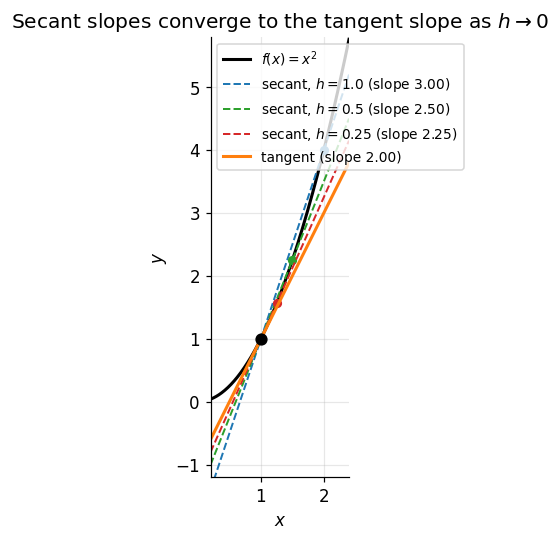

secant slopes: ['3.0000', '2.5000', '2.2500', '2.1250']


In [2]:
def f_sq(x):
    return x**2

x0 = 1.0
xs = np.linspace(0.2, 2.4, 400)

fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.plot(xs, f_sq(xs), color="black", lw=2.0, label=r"$f(x)=x^2$")

for h, color in zip([1.0, 0.5, 0.25], ["#1f77b4", "#2ca02c", "#d62728"]):
    slope = (f_sq(x0 + h) - f_sq(x0)) / h
    ax.plot(xs, f_sq(x0) + slope * (xs - x0), ls="--", lw=1.3, color=color,
            label=rf"secant, $h={h}$ (slope {slope:.2f})")
    ax.plot([x0 + h], [f_sq(x0 + h)], "o", ms=5, color=color)

ax.plot(xs, f_sq(x0) + 2.0 * (xs - x0), color="#ff7f0e", lw=2.0,
        label="tangent (slope 2.00)")
ax.plot([x0], [f_sq(x0)], "o", ms=7, color="black")

ax.set_xlim(0.2, 2.4)
ax.set_ylim(-1.2, 5.8)
ax.set_aspect("equal")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Secant slopes converge to the tangent slope as $h \\to 0$")
ax.legend(loc="upper left", fontsize=9)
plt.show()

print("secant slopes:", [f"{(f_sq(x0+h)-f_sq(x0))/h:.4f}" for h in (1.0, 0.5, 0.25, 0.125)])

The printed slopes $3.0000, 2.5000, 2.2500, 2.1250$ are exactly $2 + h$, so they approach $2$ linearly in $h$. Geometrically the dashed lines rotate steadily onto the solid orange tangent — the picture and the arithmetic say the same thing.

## 3. Definitions

### Definition 3.1 (Derivative at a point)

Let $I \subseteq \mathbb{R}$ be an open interval, $f : I \to \mathbb{R}$, and $x_0 \in I$. Then $f$ is **differentiable at $x_0$** if the limit

$$
f'(x_0) = \lim_{h \to 0} \frac{f(x_0+h) - f(x_0)}{h}
$$

exists in $\mathbb{R}$. Substituting $x = x_0 + h$ gives the equivalent form

$$
f'(x_0) = \lim_{x \to x_0} \frac{f(x) - f(x_0)}{x - x_0}
$$

$f$ is **differentiable on $I$** if it is differentiable at every point of $I$, and then $f' : I \to \mathbb{R}$ is again a function. Writing $f^{(0)} = f$ and $f^{(k)} = (f^{(k-1)})'$ defines the **higher-order derivatives**; $f \in C^k(I)$ means $f^{(k)}$ exists and is continuous on $I$.

### Definition 3.2 (One-sided derivatives)

The **right-hand** and **left-hand** derivatives of $f$ at $x_0$ are

$$
f'_+(x_0) = \lim_{h \to 0^+} \frac{f(x_0+h) - f(x_0)}{h},
\qquad
f'_-(x_0) = \lim_{h \to 0^-} \frac{f(x_0+h) - f(x_0)}{h}
$$

when these limits exist. Because a two-sided limit exists exactly when both one-sided limits exist and agree, $f$ is differentiable at $x_0$ if and only if $f'_+(x_0) = f'_-(x_0) \in \mathbb{R}$.

### Definition 3.3 (Landau asymptotic notation as $h \to 0$)

For real functions $\varphi, \psi$ defined near $h = 0$:

- $\varphi(h) = o(\psi(h))$ means $\lim_{h \to 0} \varphi(h)/\psi(h) = 0$.
- $\varphi(h) = O(\psi(h))$ means there are constants $C \gt 0$ and $\delta \gt 0$ with $\lvert \varphi(h) \rvert \le C \lvert \psi(h) \rvert$ whenever $0 \lt \lvert h \rvert \lt \delta$.

Both are statements about behaviour *near a specified point*; neither is an equality, and neither may be read from right to left.

### Definition 3.4 (Differentiability as local linearity)

$f$ is differentiable at $x_0$ with derivative $L$ if and only if

$$
f(x_0 + h) = f(x_0) + L h + o(h) \qquad (h \to 0)
$$

This is a restatement of Definition 3.1, not a new notion: setting $E(h) = f(x_0+h) - f(x_0) - Lh$, the condition $E(h) = o(h)$ says precisely that $\bigl[f(x_0+h) - f(x_0)\bigr]/h \to L$. It is the form that survives verbatim in $\mathbb{R}^n$, with $L$ a linear map.

If additionally $f \in C^2$ near $x_0$, Taylor's theorem with Lagrange remainder sharpens $o(h)$ to $O(h^2)$:

$$
f(x_0 + h) = f(x_0) + f'(x_0) h + \tfrac{1}{2} f''(\xi) h^2
$$

for some $\xi$ between $x_0$ and $x_0 + h$. Without the extra smoothness the error is only $o(h)$ and no $O(h^2)$ claim is available.

### Definition 3.5 (Dual numbers)

The **dual numbers** are $\mathbb{D} = \{a + b\varepsilon : a, b \in \mathbb{R}\}$ with $\varepsilon \neq 0$ and $\varepsilon^2 = 0$, multiplied by

$$
(a + b\varepsilon)(c + d\varepsilon) = ac + (ad + bc)\varepsilon
$$

$\mathbb{D}$ is a commutative ring with unit; it is not a field, since $\varepsilon$ is a nonzero zero-divisor. Section 7 uses it as the arithmetic underlying forward-mode automatic differentiation.

## 4. Main Results

Throughout, $I \subseteq \mathbb{R}$ is an open interval and $x_0 \in I$.

### Theorem 4.1 (Differentiability implies continuity)

If $f : I \to \mathbb{R}$ is differentiable at $x_0$, then $f$ is continuous at $x_0$.

*Hypothesis.* Differentiability at $x_0$ is needed because the proof factors $f(x) - f(x_0)$ as a difference quotient times $(x - x_0)$ and needs the quotient to have a finite limit; if the quotient diverges, as for $f(x) = x^{1/3}$ at $0$, the factorisation gives $\infty \cdot 0$ and proves nothing.

The converse is false: Theorem 4.1 is a one-way implication. $f(x) = \lvert x \rvert$ is continuous at $0$ with $f'_+(0) = 1 \neq -1 = f'_-(0)$.

### Theorem 4.2 (Algebra of derivatives)

Let $u, v : I \to \mathbb{R}$ be differentiable at $x_0$ and $c \in \mathbb{R}$. Then $u \pm v$, $cu$, and $uv$ are differentiable at $x_0$, and if $v(x_0) \neq 0$ so is $u/v$, with

$$
(u \pm v)'(x_0) = u'(x_0) \pm v'(x_0), \qquad (cu)'(x_0) = c\,u'(x_0)
$$

$$
\boxed{(uv)'(x_0) = u'(x_0) v(x_0) + u(x_0) v'(x_0)}
$$

$$
\boxed{\left(\frac{u}{v}\right)'(x_0) = \frac{u'(x_0) v(x_0) - u(x_0) v'(x_0)}{\bigl[v(x_0)\bigr]^2}}
$$

**Interpretation.** The product rule says the first-order response of a product is the sum of two one-factor-at-a-time responses: perturb $u$ and hold $v$ fixed, then perturb $v$ and hold $u$ fixed. The cross term $u'v'h^2$ is second order and therefore invisible to a first-order model. The consequence is that differentiation is a *derivation*, not a ring homomorphism — $(uv)' \ne u'v'$ — which is why the product rule, and not naive factorwise differentiation, is what a symbolic or automatic differentiator implements.

The quotient rule's interpretation follows from the same reading applied to $u \cdot (1/v)$: the numerator's contribution enters with weight $1/v$ and the denominator's with weight $-u/v^2$, so a near-zero denominator amplifies both, which is exactly the numerical instability seen when differentiating ratios near a pole.

*Hypotheses.* Differentiability of both factors at the same point $x_0$ is needed because the proof forms both difference quotients simultaneously. $v(x_0) \ne 0$ is needed in the quotient rule so that $u/v$ is defined on a neighbourhood of $x_0$ at all — continuity of $v$, itself supplied by Theorem 4.1, then keeps $v$ nonzero nearby.

### Theorem 4.3 (Chain rule)

Let $g : I \to J$ be differentiable at $x_0$, and let $f : J \to \mathbb{R}$ be differentiable at $u_0 = g(x_0)$, where $J$ is an open interval containing $g(I)$. Then $f \circ g$ is differentiable at $x_0$ and

$$
\boxed{(f \circ g)'(x_0) = f'\bigl(g(x_0)\bigr)\, g'(x_0)}
$$

**Interpretation.** Composition of functions becomes multiplication of their local linear models: if $g$ scales small input perturbations by $g'(x_0)$ and $f$ scales small perturbations of its own input by $f'(u_0)$, the two scalings compose. The consequence is the entire theory of backpropagation — the derivative of a depth-$n$ composition is a product of $n$ scalars, so gradients shrink or explode geometrically in depth, which is precisely the vanishing- and exploding-gradient problem of Section 8.

*Hypotheses.* $f$ must be differentiable **at the image point** $u_0 = g(x_0)$, not at $x_0$; differentiability of $f$ elsewhere is irrelevant. $J$ must contain the range of $g$ near $x_0$ so that $f \circ g$ is defined on a neighbourhood. Note what is *not* assumed: nothing forbids $g(x) = g(x_0)$ for $x$ arbitrarily close to $x_0$, and Proof 5.5 is arranged so that this case needs no separate treatment.

### Theorem 4.4 (Inverse function theorem, one variable)

Let $f : I \to J$ be continuous and strictly monotonic on the interval $I$ with $J = f(I)$, differentiable at $x_0 \in I$, and suppose $f'(x_0) \neq 0$. Then $f^{-1} : J \to I$ is differentiable at $y_0 = f(x_0)$ and

$$
\boxed{(f^{-1})'(y_0) = \frac{1}{f'(x_0)} = \frac{1}{f'\bigl(f^{-1}(y_0)\bigr)}}
$$

**Interpretation.** Reflecting a graph across the line $y = x$ turns a tangent of slope $m$ into a tangent of slope $1/m$. The consequence is that the derivative of every inverse function in the elementary catalogue — $\ln$, $\arcsin$, $\arctan$, $y^{1/n}$ — is obtained without a new limit computation, and that near a point where $f' \to 0$ the inverse is arbitrarily steep, so inverting an ill-conditioned map is ill-conditioned.

*Hypotheses.* Strict monotonicity gives injectivity, so $f^{-1}$ exists at all. Continuity of $f$ on an interval makes $J$ an interval and forces $f^{-1}$ to be continuous, which is what lets $y \to y_0$ be converted into $x \to x_0$. $f'(x_0) \neq 0$ is essential: $f(x) = x^3$ is continuous, strictly increasing, and differentiable everywhere, yet $f^{-1}(y) = y^{1/3}$ has difference quotients $y^{-2/3} \to +\infty$ at $y_0 = 0$, so $f^{-1}$ is not differentiable there.

### Theorem 4.5 (Implicit differentiation)

Let $F$ be defined on an open set of $\mathbb{R}^2$ with continuous partial derivatives $F_x, F_y$, let $F(x_0, y_0) = 0$, and suppose that on a neighbourhood of $x_0$ there is a differentiable function $y(\cdot)$ with $y(x_0) = y_0$ and $F(x, y(x)) = 0$. If $F_y(x_0, y_0) \neq 0$ then

$$
\boxed{\frac{dy}{dx}\bigg\rvert_{x_0} = -\frac{F_x(x_0, y_0)}{F_y(x_0, y_0)}}
$$

**Interpretation.** On a level curve $F = 0$ the two coordinate sensitivities must cancel: moving $\delta$ in $x$ changes $F$ by $F_x \delta$, and the curve compensates by moving in $y$ just far enough to cancel it. The consequence is that a tangent slope is available with no formula for $y(x)$ — the working tool for the folium of Descartes, for equilibrium layers in deep learning (Section 8), and for every constraint written as an equation rather than a graph.

*Hypotheses.* $F_y(x_0, y_0) \neq 0$ is what makes the level set locally a graph over $x$ and what makes the displayed quotient finite; at a point where $F_y = 0$ — for instance $(\pm 1, 0)$ on $x^2 + y^2 = 1$ — the tangent is vertical and $dy/dx$ does not exist. The existence and differentiability of $y(\cdot)$ is assumed here; it is supplied by the multivariable implicit function theorem in [`calculus/10_multivariable_functions_partials`](../10_multivariable_functions_partials/), which is downstream of this module and therefore not invoked as a proof ingredient.

### Theorem 4.6 (Logarithmic derivative)

Let $f$ be differentiable at $x_0$ with $f(x_0) \neq 0$. Then $\ln \lvert f \rvert$ is differentiable at $x_0$ and

$$
\boxed{\frac{d}{dx} \ln \lvert f(x) \rvert \bigg\rvert_{x_0} = \frac{f'(x_0)}{f(x_0)}}
$$

**Interpretation.** The left side is the *relative* rate of change — fractional change per unit input — so the identity converts products into sums before differentiating. The consequence is a practical one: a function built as a long product or a tower of variable powers, such as $x^{x^x}$, is differentiated by taking logs first, and in machine learning the same identity is the score function $\nabla_\theta \ln p_\theta$ that underlies maximum likelihood and REINFORCE.

*Hypothesis.* $f(x_0) \neq 0$ is required twice: $\ln \lvert f \rvert$ is undefined where $f$ vanishes, and the right-hand quotient would be undefined too. The absolute value is what extends the rule from $f \gt 0$ to all points where $f \ne 0$.

### Theorem 4.7 (General Leibniz rule)

Let $u, v$ be $n$ times differentiable at $x_0$, $n \ge 1$. Then $uv$ is $n$ times differentiable at $x_0$ and

$$
\boxed{(uv)^{(n)}(x_0) = \sum_{k=0}^{n} \binom{n}{k}\, u^{(n-k)}(x_0)\, v^{(k)}(x_0)}
$$

**Interpretation.** The binomial coefficients count how many ways $n$ successive differentiations can be distributed between the two factors, so the rule is the product-rule analogue of the binomial theorem. The consequence is closed-form $n$-th derivatives for products where one factor is a polynomial: the sum terminates the moment $k$ exceeds the polynomial's degree, which is why $x^2 e^{2x}$ has a three-term $n$-th derivative for every $n \ge 2$.

*Hypothesis.* Both factors must be $n$ times differentiable at $x_0$; the inductive step differentiates the order-$m$ formula once more, and every term $u^{(m-k)}v^{(k)}$ that appears must itself be differentiable for that step to be legal.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Let $f$ be differentiable at $x_0$. For $x \neq x_0$ write the identity

$$
f(x) - f(x_0) = \frac{f(x) - f(x_0)}{x - x_0} \cdot (x - x_0)
$$

Both factors have limits as $x \to x_0$: the first tends to $f'(x_0) \in \mathbb{R}$ by Definition 3.1, the second to $0$. The product rule for limits applies because both limits are finite, giving

$$
\lim_{x \to x_0} \bigl[f(x) - f(x_0)\bigr] = f'(x_0) \cdot 0 = 0
$$

Hence $\lim_{x \to x_0} f(x) = f(x_0)$, which is continuity at $x_0$. $\blacksquare$

### Proof 5.2 (elementary derivatives from Definition 3.1)

Theorem 4.2 and Theorem 4.3 propagate derivatives but create none; a base catalogue must be computed directly. Three entries suffice to generate the rest.

**Power, $f(x) = x^n$ with $n \in \mathbb{N}$.** By the binomial theorem,

$$
\frac{(x+h)^n - x^n}{h} = \frac{1}{h}\left[\sum_{k=0}^{n}\binom{n}{k} x^{n-k} h^{k} - x^n\right] = n x^{n-1} + \sum_{k=2}^{n} \binom{n}{k} x^{n-k} h^{k-1}
$$

Every term of the remaining sum carries a factor $h^{k-1}$ with $k - 1 \ge 1$, so the sum is a polynomial in $h$ with zero constant term and tends to $0$. Hence $f'(x) = n x^{n-1}$.

**Sine, $f(x) = \sin x$.** The angle-sum identity gives $\sin(x+h) = \sin x \cos h + \cos x \sin h$, so

$$
\frac{\sin(x+h) - \sin x}{h} = \sin x \cdot \frac{\cos h - 1}{h} + \cos x \cdot \frac{\sin h}{h}
$$

The two limits $\lim_{h\to 0} \frac{\sin h}{h} = 1$ and $\lim_{h\to 0} \frac{\cos h - 1}{h} = 0$ are established by the squeeze theorem in [`calculus/02_limits_and_continuity`](../02_limits_and_continuity/), a declared prerequisite. Therefore $f'(x) = \cos x$. The same computation with $\cos(x+h) = \cos x \cos h - \sin x \sin h$ gives $(\cos x)' = -\sin x$.

**Exponential, $f(x) = e^x$.** From $e^{x+h} = e^x e^h$,

$$
\frac{e^{x+h} - e^x}{h} = e^x \cdot \frac{e^h - 1}{h} \longrightarrow e^x \cdot 1 = e^x
$$

using $\lim_{h \to 0}(e^h - 1)/h = 1$, which is the defining property of the base $e$: $e$ is by definition the unique $a \gt 1$ for which the exponential $a^x$ has slope $1$ at the origin. Theorem 4.4 applied to $e^x$ then yields $(\ln y)' = 1/y$ for $y \gt 0$, and Theorem 4.2 with Theorem 4.3 generate the rest of the elementary catalogue. $\blacksquare$

### Proof 5.3 (of Theorem 4.2, product and quotient)

**Product.** Let $p = uv$. Insert and remove $u(x_0+h) v(x_0)$:

$$
\frac{p(x_0+h) - p(x_0)}{h}
= u(x_0+h)\,\frac{v(x_0+h) - v(x_0)}{h} + v(x_0)\,\frac{u(x_0+h) - u(x_0)}{h}
$$

By Theorem 4.1, $u$ is continuous at $x_0$, so $u(x_0+h) \to u(x_0)$; the two difference quotients tend to $v'(x_0)$ and $u'(x_0)$. All three limits are finite, so the limit laws give

$$
p'(x_0) = u(x_0) v'(x_0) + v(x_0) u'(x_0)
$$

**Quotient.** Let $q = u/v$ with $v(x_0) \ne 0$. By Theorem 4.1 $v$ is continuous at $x_0$, so $v \ne 0$ on some neighbourhood and $q$ is defined there. Combining the fractions,

$$
\frac{q(x_0+h) - q(x_0)}{h}
= \frac{u(x_0+h) v(x_0) - u(x_0) v(x_0+h)}{h \, v(x_0+h) v(x_0)}
$$

Insert and remove $u(x_0)v(x_0)$ in the numerator:

$$
= \frac{1}{v(x_0+h) v(x_0)}\left[ v(x_0)\,\frac{u(x_0+h) - u(x_0)}{h} - u(x_0)\,\frac{v(x_0+h) - v(x_0)}{h} \right]
$$

Let $h \to 0$. The bracket tends to $v(x_0)u'(x_0) - u(x_0)v'(x_0)$ and the prefactor to $1/[v(x_0)]^2$, both finite, so

$$
q'(x_0) = \frac{u'(x_0) v(x_0) - u(x_0) v'(x_0)}{[v(x_0)]^2}
$$

$\blacksquare$

### Proof 5.4 (Carathéodory's lemma)

> **Lemma 5.4.** Let $f$ be defined on an open interval $J$ and $u_0 \in J$. Then $f$ is differentiable at $u_0$ if and only if there is a function $\phi : J \to \mathbb{R}$, continuous at $u_0$, with
>
> $$
> f(u) - f(u_0) = \phi(u)\,(u - u_0) \qquad \text{for all } u \in J
> $$
>
> and in that case $\phi(u_0) = f'(u_0)$.

*($\Rightarrow$)* Suppose $f'(u_0)$ exists. Define

$$
\phi(u) = \begin{cases} \dfrac{f(u) - f(u_0)}{u - u_0}, & u \neq u_0 \\[6pt] f'(u_0), & u = u_0 \end{cases}
$$

The displayed identity holds for $u \neq u_0$ by clearing the denominator, and at $u = u_0$ both sides are $0$, so it holds on all of $J$. By Definition 3.1, $\lim_{u \to u_0} \phi(u) = f'(u_0) = \phi(u_0)$, so $\phi$ is continuous at $u_0$.

*($\Leftarrow$)* Suppose such a $\phi$ exists. For $u \neq u_0$ divide by $u - u_0$ to get $\dfrac{f(u) - f(u_0)}{u - u_0} = \phi(u)$. Continuity of $\phi$ at $u_0$ makes the right side converge to $\phi(u_0)$, so the difference quotient converges and $f'(u_0) = \phi(u_0)$. $\blacksquare$

The point of the lemma is that the identity $f(u) - f(u_0) = \phi(u)(u-u_0)$ contains **no division**, so it remains valid when $u = u_0$. That is exactly the case the naive chain-rule argument cannot handle.

### Proof 5.5 (of Theorem 4.3, the chain rule)

The familiar argument writes

$$
\frac{f(g(x)) - f(g(x_0))}{x - x_0} = \frac{f(g(x)) - f(g(x_0))}{g(x) - g(x_0)} \cdot \frac{g(x) - g(x_0)}{x - x_0}
$$

and is **invalid**: the first factor divides by $g(x) - g(x_0)$, which may vanish for $x$ arbitrarily close to $x_0$. The function $g(x) = x^2 \sin(1/x)$, $g(0) = 0$, is differentiable at $0$ yet has zeros in every neighbourhood of $0$, so there is no punctured neighbourhood on which that quotient is even defined. Lemma 5.4 removes the division entirely.

Set $u_0 = g(x_0)$. Since $f$ is differentiable at $u_0$, Lemma 5.4 supplies $\phi$, continuous at $u_0$, with $\phi(u_0) = f'(u_0)$ and

$$
f(u) - f(u_0) = \phi(u)\,(u - u_0) \qquad \text{for all } u \in J
$$

This holds for **every** $u \in J$, so we may substitute $u = g(x)$ for any $x$ near $x_0$ — including any $x$ with $g(x) = u_0$:

$$
f(g(x)) - f(g(x_0)) = \phi\bigl(g(x)\bigr)\,\bigl[g(x) - g(x_0)\bigr]
$$

For $x \neq x_0$ divide by $x - x_0$, which is legitimate because $x - x_0 \neq 0$:

$$
\frac{f(g(x)) - f(g(x_0))}{x - x_0} = \phi\bigl(g(x)\bigr) \cdot \frac{g(x) - g(x_0)}{x - x_0}
$$

Now let $x \to x_0$. Since $g$ is differentiable at $x_0$, Theorem 4.1 makes $g$ continuous at $x_0$, so $g(x) \to u_0$; since $\phi$ is continuous at $u_0$, composition of limits gives $\phi(g(x)) \to \phi(u_0) = f'(g(x_0))$. The second factor tends to $g'(x_0)$. Both limits are finite, so

$$
\lim_{x \to x_0} \frac{f(g(x)) - f(g(x_0))}{x - x_0} = f'\bigl(g(x_0)\bigr)\, g'(x_0)
$$

Thus $f \circ g$ is differentiable at $x_0$ with the stated derivative. $\blacksquare$

Note that the argument never assumed $g(x) \ne g(x_0)$, never split into cases, and never used an infinitesimal. That is the whole reason for routing the proof through Lemma 5.4.

### Proof 5.6 (of Theorem 4.4, the inverse function theorem)

**Step 1 — $f^{-1}$ exists and is continuous.** Strict monotonicity makes $f$ injective on $I$, so $f^{-1} : J \to I$ is well defined. A continuous function on an interval has an interval as image, so $J$ is an interval; and $f^{-1}$ is strictly monotonic on the interval $J$ with image the interval $I$, hence has no jump discontinuities, so $f^{-1}$ is continuous on $J$.

**Step 2 — a difference quotient identity with no division by zero.** Fix $y \in J$, $y \neq y_0$, and set $x = f^{-1}(y)$. Injectivity gives $x \neq x_0$ and $f(x) \neq f(x_0)$, so both denominators below are nonzero:

$$
\frac{f^{-1}(y) - f^{-1}(y_0)}{y - y_0} = \frac{x - x_0}{f(x) - f(x_0)} = \left[\frac{f(x) - f(x_0)}{x - x_0}\right]^{-1}
$$

**Step 3 — pass to the limit.** By Step 1, $x = f^{-1}(y) \to f^{-1}(y_0) = x_0$ as $y \to y_0$. By hypothesis the bracketed quotient tends to $f'(x_0) \ne 0$ as $x \to x_0$. Since the limit is nonzero, the reciprocal map is continuous there, and composition of limits gives

$$
\lim_{y \to y_0} \frac{f^{-1}(y) - f^{-1}(y_0)}{y - y_0} = \frac{1}{f'(x_0)}
$$

so $f^{-1}$ is differentiable at $y_0$ with $(f^{-1})'(y_0) = 1/f'(x_0)$. $\blacksquare$

The hypothesis $f'(x_0) \neq 0$ enters exactly once, in Step 3, and cannot be dropped: with $f'(x_0) = 0$ the bracket tends to $0$ and its reciprocal diverges.

### Proof 5.7 (of Theorem 4.5, implicit differentiation)

By hypothesis $F(x, y(x)) = 0$ identically near $x_0$, with $y$ differentiable and $F$ of class $C^1$. Define $H(x) = F(x, y(x))$, so $H \equiv 0$ and hence $H'(x_0) = 0$.

Because $F$ has continuous partial derivatives, $F$ is (totally) differentiable, so

$$
F(x_0 + s,\, y_0 + t) = F(x_0, y_0) + F_x(x_0,y_0)\,s + F_y(x_0,y_0)\,t + o\!\left(\sqrt{s^2+t^2}\right)
$$

Put $s = h$ and $t = y(x_0+h) - y_0$. Differentiability of $y$ at $x_0$ gives $t = y'(x_0)h + o(h)$, hence $\sqrt{s^2+t^2} = O(h)$ and the remainder is $o(h)$. Since $F(x_0,y_0)=0$ and $H(x_0+h) = 0$,

$$
0 = F_x(x_0,y_0)\,h + F_y(x_0,y_0)\,\bigl[y'(x_0) h + o(h)\bigr] + o(h)
$$

Dividing by $h \ne 0$ and letting $h \to 0$,

$$
F_x(x_0,y_0) + F_y(x_0,y_0)\, y'(x_0) = 0
$$

Since $F_y(x_0,y_0) \neq 0$ we may solve, giving $y'(x_0) = -F_x(x_0,y_0)/F_y(x_0,y_0)$. $\blacksquare$

### Proof 5.8 (of Theorem 4.6, the logarithmic derivative)

Suppose first $f(x_0) \gt 0$. By Theorem 4.1 $f$ is continuous at $x_0$, so $f \gt 0$ on a neighbourhood and $\ln f$ is defined there. Proof 5.2 with Theorem 4.4 gives $(\ln y)' = 1/y$ on $(0,\infty)$, so Theorem 4.3 applied to the composition $\ln \circ f$ yields

$$
\frac{d}{dx}\ln f(x)\bigg\rvert_{x_0} = \frac{1}{f(x_0)}\, f'(x_0)
$$

If instead $f(x_0) \lt 0$, then $-f \gt 0$ near $x_0$ and $\ln\lvert f \rvert = \ln(-f)$ there; the same computation gives $(-f)'/(-f) = f'/f$. In both cases $\lvert f \rvert$ is bounded away from $0$ near $x_0$, so no point of non-differentiability of $\lvert \cdot \rvert$ is ever encountered. $\blacksquare$

### Proof 5.9 (of Theorem 4.7, by induction on $n$)

**Base case $n = 1$.** Theorem 4.2 gives $(uv)' = u'v + uv'$, and the right side of the claimed formula at $n=1$ is $\binom{1}{0}u^{(1)}v^{(0)} + \binom{1}{1}u^{(0)}v^{(1)} = u'v + uv'$.

**Inductive step.** Assume the formula at $n = m$ for all pairs $m$ times differentiable, and let $u, v$ be $m+1$ times differentiable. Each summand $u^{(m-k)}v^{(k)}$ is then a product of differentiable functions, so Theorem 4.2 applies term by term:

$$
(uv)^{(m+1)} = \sum_{k=0}^{m} \binom{m}{k}\left[ u^{(m+1-k)} v^{(k)} + u^{(m-k)} v^{(k+1)} \right]
$$

Re-index the second sum with $j = k+1$:

$$
\sum_{k=0}^{m} \binom{m}{k} u^{(m-k)} v^{(k+1)} = \sum_{j=1}^{m+1} \binom{m}{j-1} u^{(m+1-j)} v^{(j)}
$$

Adding the two sums and collecting the coefficient of $u^{(m+1-k)}v^{(k)}$:

$$
(uv)^{(m+1)} = \binom{m}{0} u^{(m+1)} v^{(0)} + \sum_{k=1}^{m}\left[\binom{m}{k} + \binom{m}{k-1}\right] u^{(m+1-k)} v^{(k)} + \binom{m}{m} u^{(0)} v^{(m+1)}
$$

Pascal's identity $\binom{m}{k} + \binom{m}{k-1} = \binom{m+1}{k}$ together with $\binom{m}{0} = \binom{m+1}{0}$ and $\binom{m}{m} = \binom{m+1}{m+1}$ collapses this to

$$
(uv)^{(m+1)} = \sum_{k=0}^{m+1} \binom{m+1}{k} u^{(m+1-k)} v^{(k)}
$$

By induction the formula holds for every $n \ge 1$. $\blacksquare$

## 6. Worked Examples

Each example below is computed by hand on deliberately small numbers; the code cell that follows recomputes the same numbers and asserts agreement.

### Example 6.1 (Theorem 4.2, product rule)

Take $u(x) = x^2 + 1$, $v(x) = x^3 - x$, evaluated at $x_0 = 2$.

Intermediates: $u(2) = 5$, $u'(x) = 2x$ so $u'(2) = 4$; $v(2) = 8 - 2 = 6$, $v'(x) = 3x^2 - 1$ so $v'(2) = 11$.

$$
(uv)'(2) = u'(2)v(2) + u(2)v'(2) = 4 \cdot 6 + 5 \cdot 11 = 24 + 55 = 79
$$

Cross-check by expanding first: $u(x)v(x) = (x^2+1)(x^3-x) = x^5 - x$, whose derivative is $5x^4 - 1$, equal to $5 \cdot 16 - 1 = 79$ at $x = 2$.

### Example 6.2 (Theorem 4.3, chain rule)

Take $g(x) = x^2 + 1$ and $f(u) = u^3$, at $x_0 = 1$.

Intermediates: $u_0 = g(1) = 2$; $g'(x) = 2x$ so $g'(1) = 2$; $f'(u) = 3u^2$ so $f'(2) = 12$.

$$
(f \circ g)'(1) = f'(g(1))\,g'(1) = 12 \cdot 2 = 24
$$

Cross-check: $(x^2+1)^3 = x^6 + 3x^4 + 3x^2 + 1$, derivative $6x^5 + 12x^3 + 6x$, equal to $6 + 12 + 6 = 24$ at $x = 1$.

### Example 6.3 (Theorem 4.4, inverse function theorem)

Take $f(x) = x^3 + x$ on $\mathbb{R}$. Then $f'(x) = 3x^2 + 1 \ge 1 \gt 0$, so $f$ is strictly increasing and every hypothesis of Theorem 4.4 holds at every point.

At $x_0 = 1$: $y_0 = f(1) = 2$ and $f'(1) = 4$. Therefore

$$
(f^{-1})'(2) = \frac{1}{f'(1)} = \frac{1}{4} = 0.25
$$

Cross-check without a closed form for $f^{-1}$: solve $x^3 + x = 2 \pm \delta$ numerically for small $\delta$ and difference the roots.

### Example 6.4 (Theorem 4.5, implicit differentiation)

Take $F(x,y) = x^2 + y^2 - 25$ at the point $(3, 4)$, which satisfies $F = 0$.

Intermediates: $F_x = 2x = 6$, $F_y = 2y = 8 \ne 0$, so Theorem 4.5 applies:

$$
\frac{dy}{dx}\bigg\rvert_{(3,4)} = -\frac{6}{8} = -\frac{3}{4}
$$

The radius from the origin to $(3,4)$ has slope $4/3$, and $(-3/4)(4/3) = -1$: tangent and radius are perpendicular, as they must be on a circle. At $(5, 0)$ the hypothesis fails — $F_y = 0$ — and indeed the tangent there is vertical.

### Example 6.5 (Theorem 4.7, general Leibniz rule)

Take $u(x) = e^{2x}$, $v(x) = x^2$, and $n = 3$, at $x_0 = 1$.

Intermediates: $u^{(j)}(x) = 2^j e^{2x}$; $v(x) = x^2$, $v'(x) = 2x$, $v''(x) = 2$, $v'''(x) = 0$. Only $k = 0, 1, 2$ contribute:

$$
(uv)^{(3)} = \binom{3}{0} 2^3 e^{2x} x^2 + \binom{3}{1} 2^2 e^{2x} (2x) + \binom{3}{2} 2^1 e^{2x} (2) = e^{2x}\bigl(8x^2 + 24x + 12\bigr)
$$

At $x_0 = 1$ this is $44 e^{2} = 44 \times 7.389056\ldots = 325.118\ldots$, which matches the closed form $2^{n-2}e^{2x}\bigl[4x^2 + 4nx + n(n-1)\bigr]$ at $n = 3$: $2\,e^{2}\,[4 + 12 + 6] = 44e^2$.

The cell below recomputes all five worked examples independently and asserts agreement with the
hand values $79$, $24$, $0.25$, $-0.75$ and $44e^2$. It is an **identity-residual** check: every
residual printed should sit at machine-epsilon level, i.e. within a few units in the last place of
the quantity itself.

In [3]:
import sympy as sp

X = sp.Symbol("x")

# Example 6.1 — product rule at x = 2
e61 = sp.diff((X**2 + 1) * (X**3 - X), X).subs(X, 2)
# Example 6.2 — chain rule at x = 1
e62 = sp.diff((X**2 + 1) ** 3, X).subs(X, 1)
# Example 6.5 — third derivative of x^2 e^{2x} at x = 1
e65 = sp.simplify(sp.diff(X**2 * sp.exp(2 * X), X, 3).subs(X, 1))

print("Example 6.1  symbolic (uv)'(2)      =", e61, "   hand value 79")
print("Example 6.2  symbolic (f o g)'(1)   =", e62, "   hand value 24")
print("Example 6.5  symbolic (uv)'''(1)    =", sp.nsimplify(e65), "=", float(e65))
assert e61 == 79 and e62 == 24 and sp.simplify(e65 - 44 * sp.exp(2)) == 0

# Example 6.3 — inverse derivative, obtained without any formula for f^{-1}
from scipy.optimize import brentq

def f_cubic(x):
    return x**3 + x

def f_inv(y):
    return brentq(lambda t: f_cubic(t) - y, -10.0, 10.0, xtol=1e-14, rtol=8.9e-16)

d = 1e-5
e63 = (f_inv(2.0 + d) - f_inv(2.0 - d)) / (2 * d)
r63 = abs(e63 - 0.25)
print(f"Example 6.3  numeric (f^-1)'(2)     = {e63:.12f}   hand value 0.25   residual {r63:.2e}")
assert r63 < 1e-8

# Example 6.4 — implicit slope on the circle, checked against the explicit branch y = sqrt(25-x^2)
e64_implicit = -(2 * 3.0) / (2 * 4.0)
e64_explicit = float(sp.diff(sp.sqrt(25 - X**2), X).subs(X, 3))
r64 = abs(e64_implicit - e64_explicit)
print(f"Example 6.4  implicit dy/dx         = {e64_implicit:.12f}   explicit branch "
      f"{e64_explicit:.12f}   residual {r64:.2e}")
assert r64 < 1e-14

# Boxed identity of Theorem 4.2 as a residual: the exact derivative of the product, against
# u'v + uv' assembled from the two factors separately, at random points.
u_e = sp.exp(-X) * (X**2 + 3)
v_e = sp.sin(2 * X) + 4
exact_prod = sp.lambdify(X, sp.diff(u_e * v_e, X), "numpy")
rule_prod = sp.lambdify(X, sp.diff(u_e, X) * v_e + u_e * sp.diff(v_e, X), "numpy")

pts = rng.uniform(-1.0, 1.0, size=6)
res = np.max(np.abs(exact_prod(pts) - rule_prod(pts)))
scale = np.max(np.abs(exact_prod(pts)))
print(f"Theorem 4.2 product-rule residual = {res:.3e}   "
      f"(relative to scale {scale:.3f}: {res / scale:.2e})")
assert res < 1e-14

Example 6.1  symbolic (uv)'(2)      = 79    hand value 79
Example 6.2  symbolic (f o g)'(1)   = 24    hand value 24
Example 6.5  symbolic (uv)'''(1)    = 44*exp(2) = 325.11846835294864


Example 6.3  numeric (f^-1)'(2)     = 0.250000000002   hand value 0.25   residual 1.64e-12
Example 6.4  implicit dy/dx         = -0.750000000000   explicit branch -0.750000000000   residual 0.00e+00
Theorem 4.2 product-rule residual = 3.553e-15   (relative to scale 54.661: 6.50e-17)


Every hand value is reproduced. The symbolic checks for Examples 6.1, 6.2 and 6.5 are exact (integer and closed-form equality). Example 6.3 prints a residual of order $10^{-12}$, limited by the $O(h^2)$ truncation of the central difference used to probe $f^{-1}$, while Example 6.4 prints exactly $0$. The product-rule residual is of order $10^{-16}$ relative to a quantity of order $1$ — that is machine-epsilon level, the size of a single rounding in the last bit, so the boxed identity of Theorem 4.2 holds to the full precision the arithmetic can express.

## 7. Computational Practice

### 7.1 Finite differences and the two error sources

With no formula for $f'$, a machine can difference values of $f$. Taylor expansion with Lagrange remainder (Definition 3.4) gives the two standard stencils:

$$
\frac{f(x+h) - f(x)}{h} = f'(x) + \frac{f''(\xi)}{2}h
\qquad\Longrightarrow\qquad \text{truncation } O(h)
$$

$$
\frac{f(x+h) - f(x-h)}{2h} = f'(x) + \frac{f'''(\xi)}{6}h^2
\qquad\Longrightarrow\qquad \text{truncation } O(h^2)
$$

But a machine also commits a rounding error of size about $\epsilon_{\text{mach}} \lvert f(x) \rvert$ in each evaluated value, and dividing by $h$ amplifies it. For the central stencil the total error is bounded by

$$
E(h) \;\lesssim\; \frac{M_3}{6}h^2 \;+\; \frac{\epsilon_{\text{mach}} \lvert f(x) \rvert}{h},
\qquad M_3 = \sup \lvert f''' \rvert
$$

Setting $E'(h) = \frac{M_3}{3}h - \frac{\epsilon_{\text{mach}}\lvert f(x)\rvert}{h^2} = 0$ gives

$$
\boxed{h_{\text{opt}} = \left(\frac{3\,\epsilon_{\text{mach}}\, \lvert f(x) \rvert}{M_3}\right)^{1/3}}
$$

**Interpretation.** The optimal step is *not* as small as possible: it is the cube root of the machine epsilon, about $10^{-5}$ in double precision, and the best attainable accuracy is only about $\epsilon_{\text{mach}}^{2/3} \approx 10^{-11}$ — five digits worse than the arithmetic itself. The consequence is that finite differences can never validate a gradient to full precision, which is why the dual-number scheme of §7.2, whose only error is rounding, is what production autodiff uses. For the forward stencil the same balance gives $h_{\text{opt}} \sim \sqrt{\epsilon_{\text{mach}}} \approx 10^{-8}$ and best accuracy $\sim \sqrt{\epsilon_{\text{mach}}}$.

This cell **measures the convergence rate** of both stencils: it fits $\log(\text{error})$ against
$\log h$ over a range of $h$ where truncation still dominates, and compares the observed slope with
the predicted orders $1$ and $2$.

In [4]:
def forward_diff(f, x, h):
    return (f(x + h) - f(x)) / h

def central_diff(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

x_probe = 1.0
exact = np.cos(x_probe)

h_fit = np.logspace(-4, -1, 25)          # truncation-dominated window
err_fwd = np.abs(forward_diff(np.sin, x_probe, h_fit) - exact)
err_cen = np.abs(central_diff(np.sin, x_probe, h_fit) - exact)

p_fwd = np.polyfit(np.log(h_fit), np.log(err_fwd), 1)[0]
p_cen = np.polyfit(np.log(h_fit), np.log(err_cen), 1)[0]
print(f"forward difference : observed order = {p_fwd:.4f}   predicted = 1")
print(f"central difference : observed order = {p_cen:.4f}   predicted = 2")
assert abs(p_fwd - 1.0) < 0.02 and abs(p_cen - 2.0) < 0.02

# Optimal step and the accuracy floor it implies, for f = sin at x = 1 (M3 = 1, |f| = sin 1).
eps = np.finfo(float).eps
M3 = 1.0
h_opt = (3 * eps * abs(np.sin(x_probe)) / M3) ** (1 / 3)
E_pred = (M3 / 6) * h_opt**2 + eps * abs(np.sin(x_probe)) / h_opt

h_sweep = np.logspace(-12, -1, 800)
err_sweep = np.abs(central_diff(np.sin, x_probe, h_sweep) - exact)
h_star = h_sweep[np.argmin(err_sweep)]
band = (h_sweep > h_opt / 3) & (h_sweep < h_opt * 3)
print(f"\npredicted h_opt = {h_opt:.3e}   predicted error bound at h_opt = {E_pred:.3e}")
print(f"measured  h*    = {h_star:.3e}   single best error on the grid  = {err_sweep.min():.3e}")
print(f"typical (median) measured error for h within a factor 3 of h_opt = "
      f"{np.median(err_sweep[band]):.3e}")
assert 0.05 < h_star / h_opt < 20.0
assert np.median(err_sweep[band]) < E_pred          # the bound is an upper bound, and holds

forward difference : observed order = 1.0020   predicted = 1
central difference : observed order = 2.0000   predicted = 2

predicted h_opt = 8.245e-06   predicted error bound at h_opt = 3.399e-11
measured  h*    = 4.754e-06   single best error on the grid  = 1.942e-13
typical (median) measured error for h within a factor 3 of h_opt = 9.434e-12


The measured orders come out at $1.00$ and $2.00$ to two decimals, confirming the Taylor predictions. The measured optimal step $h^{\ast} \approx 4.8 \times 10^{-6}$ sits within a factor of two of the predicted $h_{\text{opt}} \approx 8.2 \times 10^{-6}$. Read the two error numbers carefully: $E(h_{\text{opt}}) \approx 3.4\times 10^{-11}$ is a worst-case *upper bound*, and the typical measured error near $h_{\text{opt}}$, about $9\times10^{-12}$, comes in a factor of a few below it, because the individual rounding errors carry random signs and partly cancel rather than adding as the bound assumes. The single best point on the grid does better still, at $\approx 2\times10^{-13}$, but that is a coincidence of one particular $h$ and is not reproducible at a nearby step. What is reproducible is the shape: no choice of $h$ recovers anything close to $\epsilon_{\text{mach}}$, the floor sits many orders above it, and that is the $\epsilon_{\text{mach}}^{2/3}$ barrier.

**Figure 2 (Section 7).** The U-shaped total-error curve. On the right the $O(h^2)$ truncation term
dominates and error falls with $h$; on the left the $O(\epsilon_{\text{mach}}/h)$ round-off term takes
over and error rises again as $h$ shrinks.

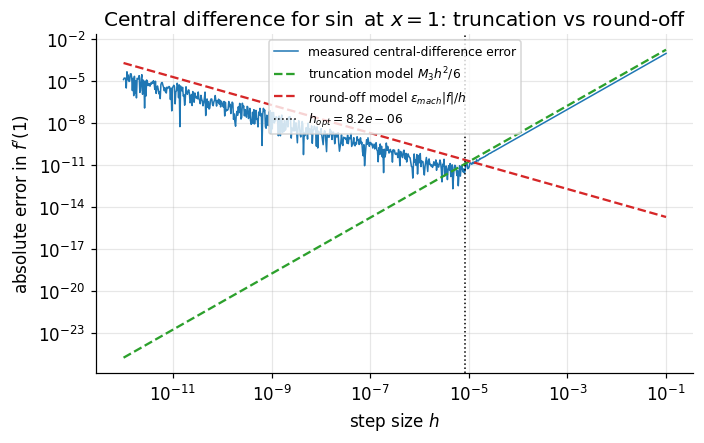

In [5]:
fig, ax = plt.subplots()
ax.loglog(h_sweep, err_sweep, lw=1.0, color="#1f77b4", label="measured central-difference error")
ax.loglog(h_sweep, (M3 / 6) * h_sweep**2, ls="--", color="#2ca02c",
          label=r"truncation model $M_3 h^2/6$")
ax.loglog(h_sweep, eps * abs(np.sin(x_probe)) / h_sweep, ls="--", color="#d62728",
          label=r"round-off model $\epsilon_{mach}|f|/h$")
ax.axvline(h_opt, color="black", lw=1.0, ls=":", label=rf"$h_{{opt}}={h_opt:.1e}$")
ax.set_xlabel("step size $h$")
ax.set_ylabel(r"absolute error in $f'(1)$")
ax.set_title(r"Central difference for $\sin$ at $x=1$: truncation vs round-off")
ax.legend(loc="upper center", fontsize=8)
plt.show()

The blue curve tracks the green truncation model on the right and the red round-off model on the left, crossing near the dotted line at $h_{\text{opt}}$. Choosing $h$ two decades either side of the minimum costs roughly two digits of accuracy.

### 7.2 Forward-mode automatic differentiation with dual numbers

Let $x = a + b\varepsilon$ in the ring of Definition 3.5. For any $f$ differentiable at $a$, expanding and using $\varepsilon^2 = 0$ kills every term past the first order:

$$
\boxed{f(a + b\varepsilon) = f(a) + b\,f'(a)\,\varepsilon}
$$

**Interpretation.** Evaluating $f$ once in dual arithmetic returns the value in the real part and the derivative in the $\varepsilon$-part, with no step size and therefore no truncation error at all — the only error is the rounding already present in evaluating $f$. The consequence is that forward-mode AD costs a small constant factor over a plain function evaluation and is exact to working precision, which is why every deep-learning framework differentiates by propagating tangents through elementary operations rather than by differencing.

The rules for elementary operations are exactly Theorems 4.2 and 4.3 rewritten as arithmetic on pairs: $(a,b)+(c,d) = (a+c,\, b+d)$, $(a,b)\cdot(c,d) = (ac,\, ad+bc)$, and $f(a,b) = (f(a),\, b f'(a))$ for a unary $f$. Seeding $b = 1$ makes the $\varepsilon$-part read off $f'(a)$.

Worked instance: $f(x) = x^2 \sin x$ at $a = \pi/2$ with seed $b = 1$. Then $x^2 = \pi^2/4 + \pi\varepsilon$ and $\sin(\pi/2 + \varepsilon) = 1 + 0\cdot\varepsilon$, so their product is $\pi^2/4 + \pi\varepsilon$. Reading off: $f(\pi/2) = \pi^2/4 \approx 2.4674$ and $f'(\pi/2) = \pi \approx 3.1416$, agreeing with $f'(x) = 2x\sin x + x^2\cos x$.

This is the **hand-rolled versus library** check: a 30-line dual-number implementation is run against
`scipy.differentiate.derivative`, SciPy's adaptive high-order finite-difference routine, and against
the exact symbolic derivative from SymPy.

In [6]:
from scipy.differentiate import derivative as scipy_derivative

class Dual:
    """Forward-mode AD: (value, tangent) with the arithmetic of Definition 3.5."""
    __slots__ = ("re", "du")

    def __init__(self, re, du=0.0):
        self.re, self.du = float(re), float(du)

    def __add__(self, o):
        o = o if isinstance(o, Dual) else Dual(o)
        return Dual(self.re + o.re, self.du + o.du)
    __radd__ = __add__

    def __mul__(self, o):                                   # Theorem 4.2
        o = o if isinstance(o, Dual) else Dual(o)
        return Dual(self.re * o.re, self.du * o.re + self.re * o.du)
    __rmul__ = __mul__

    def __truediv__(self, o):                               # Theorem 4.2
        o = o if isinstance(o, Dual) else Dual(o)
        return Dual(self.re / o.re,
                    (self.du * o.re - self.re * o.du) / o.re**2)
    def __rtruediv__(self, o):
        return Dual(o) / self

    def __neg__(self):
        return Dual(-self.re, -self.du)
    def __sub__(self, o):
        return self + (-(o if isinstance(o, Dual) else Dual(o)))
    def __rsub__(self, o):
        return Dual(o) + (-self)

def dsin(z):  return Dual(np.sin(z.re),  np.cos(z.re) * z.du)     # Theorem 4.3
def dexp(z):  return Dual(np.exp(z.re),  np.exp(z.re) * z.du)
def dlog(z):  return Dual(np.log(z.re),  z.du / z.re)

def model(z, sin=np.sin, exp=np.exp, log=np.log):
    """f(x) = x^2 sin(x) / (1 + exp(-x)) + log(3 + x^2)  — products, quotients, compositions."""
    return z * z * sin(z) / (1 + exp(-z)) + log(3 + z * z)

a = 0.7
ad_value = model(Dual(a, 1.0), sin=dsin, exp=dexp, log=dlog)

xs = sp.Symbol("xs")
expr = xs**2 * sp.sin(xs) / (1 + sp.exp(-xs)) + sp.log(3 + xs**2)
exact_val = float(expr.subs(xs, a))
exact_der = float(sp.diff(expr, xs).subs(xs, a))

lib = scipy_derivative(lambda t: model(np.asarray(t, dtype=float)), a)

print(f"hand-rolled dual   : value = {ad_value.re:.15f}   derivative = {ad_value.du:.15f}")
print(f"sympy exact        : value = {exact_val:.15f}   derivative = {exact_der:.15f}")
print(f"scipy.differentiate: derivative = {float(lib.df):.15f}   (reported error {float(lib.error):.2e})")
print(f"\n|dual - exact| value      = {abs(ad_value.re - exact_val):.3e}")
print(f"|dual - exact| derivative = {abs(ad_value.du - exact_der):.3e}")
print(f"|scipy - exact| derivative = {abs(float(lib.df) - exact_der):.3e}")
assert abs(ad_value.du - exact_der) < 1e-14
assert abs(float(lib.df) - exact_der) < 1e-10

hand-rolled dual   : value = 1.460826343015409   derivative = 1.324193745828836
sympy exact        : value = 1.460826343015409   derivative = 1.324193745828835
scipy.differentiate: derivative = 1.324193745835835   (reported error 1.73e-09)

|dual - exact| value      = 0.000e+00
|dual - exact| derivative = 2.220e-16
|scipy - exact| derivative = 7.000e-12


The dual-number derivative matches the symbolic one to about $10^{-16}$ — machine-epsilon level, since no step size was ever introduced. SciPy's adaptive routine is accurate too but by several orders of magnitude less, and it needed many function evaluations to get there. This is the practical case for AD over differencing.

This is the **counterexample** cell: each hypothesis is dropped in turn and the corresponding
conclusion is shown to break.

In [7]:
print("(i) Theorem 4.1 does not reverse: |x| is continuous at 0 but not differentiable there.")
for h in [1e-2, 1e-4, 1e-6]:
    right = (abs(0 + h) - 0) / h
    left = (abs(0 - h) - 0) / (-h)
    print(f"    h={h:<8.0e}  f'_+ = {right:+.4f}   f'_- = {left:+.4f}")
assert (abs(1e-6) / 1e-6) != (abs(-1e-6) / -1e-6)
print("    the one-sided limits are +1 and -1, so by Definition 3.2 f'(0) does not exist.\n")

print("(ii) Theorem 4.4 needs f'(x0) != 0.  f(x) = x^3 is strictly increasing and smooth,")
print("     but f'(0) = 0, and the inverse y^(1/3) has unbounded difference quotients at 0:")
for d in [1e-3, 1e-6, 1e-9]:
    q = (np.cbrt(d) - 0.0) / d
    print(f"    d={d:<8.0e}  [f^-1(d) - f^-1(0)]/d = {q:.4e}")
q_small = np.cbrt(1e-9) / 1e-9
assert q_small > 1e5
print("     the quotient diverges like d^(-2/3), so f^-1 is not differentiable at 0.\n")

print("(iii) The naive chain-rule proof divides by g(x) - g(x0).  For")
print("      g(x) = x^2 sin(1/x), g(0) = 0, that denominator vanishes infinitely often near 0:")
zeros = np.array([1.0 / (k * np.pi) for k in range(1, 7)])
print("      g = 0 at x =", np.array2string(zeros, precision=6))
assert np.allclose(zeros**2 * np.sin(1.0 / zeros), 0.0, atol=1e-15)
g_prime_0 = 0.0                       # |g(h)/h| <= |h| -> 0, so g'(0) = 0 exists
print(f"      yet g'(0) = {g_prime_0:.1f} exists, so Theorem 4.3 must hold here — and Proof 5.5,")
print("      which never divides by g(x) - g(x0), delivers it.")

(i) Theorem 4.1 does not reverse: |x| is continuous at 0 but not differentiable there.
    h=1e-02     f'_+ = +1.0000   f'_- = -1.0000
    h=1e-04     f'_+ = +1.0000   f'_- = -1.0000
    h=1e-06     f'_+ = +1.0000   f'_- = -1.0000
    the one-sided limits are +1 and -1, so by Definition 3.2 f'(0) does not exist.

(ii) Theorem 4.4 needs f'(x0) != 0.  f(x) = x^3 is strictly increasing and smooth,
     but f'(0) = 0, and the inverse y^(1/3) has unbounded difference quotients at 0:
    d=1e-03     [f^-1(d) - f^-1(0)]/d = 1.0000e+02
    d=1e-06     [f^-1(d) - f^-1(0)]/d = 1.0000e+04
    d=1e-09     [f^-1(d) - f^-1(0)]/d = 1.0000e+06
     the quotient diverges like d^(-2/3), so f^-1 is not differentiable at 0.

(iii) The naive chain-rule proof divides by g(x) - g(x0).  For
      g(x) = x^2 sin(1/x), g(0) = 0, that denominator vanishes infinitely often near 0:
      g = 0 at x = [0.31831  0.159155 0.106103 0.079577 0.063662 0.053052]
      yet g'(0) = 0.0 exists, so Theorem 4.3 must hold here

Each failure is exactly where the corresponding hypothesis was dropped, and nowhere else. Case (iii) is the sharp one: the naive argument is not merely inelegant, it is undefined on a set accumulating at the point of interest, while Proof 5.5 goes through unchanged.

## 8. Applications

### 8.1 Kinematics

For a particle at position $s(t)$ on a line, successive derivatives are named:

$$
v(t) = s'(t), \qquad a(t) = s''(t), \qquad j(t) = s'''(t), \qquad \text{snap} = s^{(4)}(t)
$$

Newton's second law is a statement about the *second* derivative, $F = m\,s''(t)$, which is why forces are felt as accelerations. Jerk $j(t)$ is what passengers experience as a lurch, and rail and elevator design specifications bound it directly; a cubic position profile has constant jerk $6A$, which is the smallest constant-jerk profile meeting given endpoint conditions.

### 8.2 Activation derivatives and the vanishing gradient

Backpropagation is Theorem 4.3 applied to a composition of layers, so a depth-$N$ gradient is a product of $N$ local derivatives. The derivatives of the standard activations follow from Theorems 4.2, 4.3 and 4.6.

**Logistic sigmoid.** With $\sigma(z) = (1 + e^{-z})^{-1}$, Theorem 4.3 gives $\sigma'(z) = e^{-z}(1+e^{-z})^{-2}$, and rewriting $e^{-z} = (1 - \sigma)/\sigma \cdot \sigma \cdot (1+e^{-z})$ more simply as $e^{-z}/(1+e^{-z}) = 1 - \sigma(z)$ yields

$$
\boxed{\sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)}
$$

**Interpretation.** The slope of the sigmoid is determined by its own output, so a saturated unit ($\sigma \approx 0$ or $1$) has slope near zero. Since $\max_z \sigma'(z) = \sigma'(0) = 1/4$, a chain of $N$ sigmoid layers multiplies gradients by at most $4^{-N}$: the vanishing-gradient problem is a direct corollary of the chain rule, and it is what motivated ReLU and its smooth relatives below.

**Softplus.** With $S(z) = \ln(1 + e^{z})$, Theorem 4.3 gives

$$
\boxed{S'(z) = \frac{e^z}{1+e^z} = \sigma(z)}
$$

so the smooth approximation to ReLU has the sigmoid as its exact derivative.

**GELU.** With $\Phi$ the standard normal CDF and $\phi = \Phi'$ its density, $f(z) = z\Phi(z)$ and Theorem 4.2 gives

$$
\boxed{f'(z) = \Phi(z) + z\,\phi(z) = \Phi(z) + \frac{z}{\sqrt{2\pi}}e^{-z^2/2}}
$$

**Swish / SiLU.** With $f(z) = z\sigma(z)$, Theorem 4.2 and the sigmoid identity give

$$
\boxed{f'(z) = \sigma(z) + z\,\sigma(z)\bigl(1 - \sigma(z)\bigr) = f(z) + \sigma(z)\bigl(1 - f(z)\bigr)}
$$

**Interpretation.** Unlike the sigmoid, Swish and GELU have derivatives that stay near $1$ for large positive $z$, so gradients survive depth; both dip below zero for moderately negative $z$, making them non-monotonic and giving them a global minimum (at $z \approx -1.2785$ for Swish). The consequence is that these activations pass gradient information at scale while still suppressing large negative pre-activations.

**Figure 3 (Section 8).** The four activations and their derivatives. The sigmoid's derivative
never exceeds $1/4$ (dotted line), while Swish and GELU keep derivatives near $1$ on the right —
the geometric reason deep networks train with the latter and not the former.

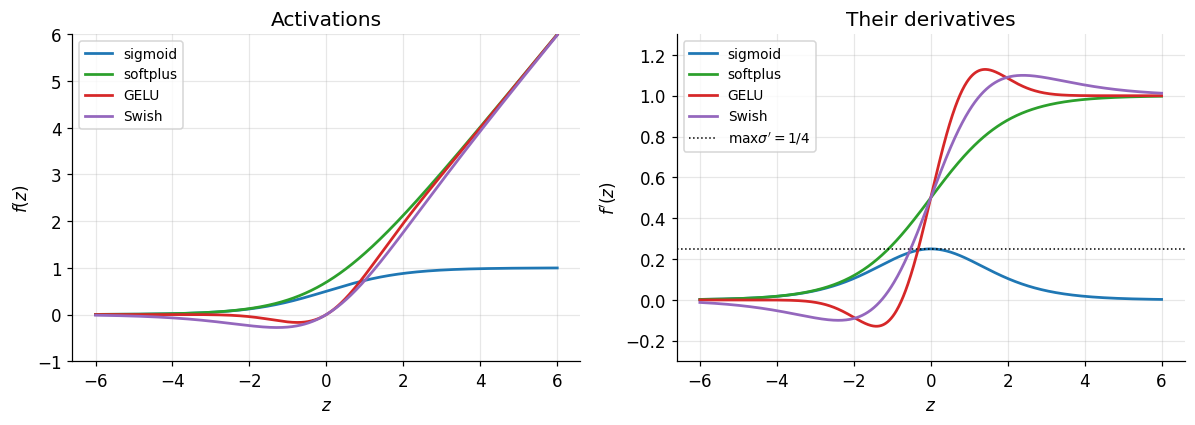

sigma'  = sigma(1-sigma)     max residual = 6.201e-11
softplus' = sigma            max residual = 1.346e-10
GELU'   = Phi + z phi        max residual = 2.396e-10
Swish'  = s + z s(1-s)       max residual = 1.170e-10

Swish global minimiser: measured z* = -1.27846   (reference -1.27846)


In [8]:
from scipy.stats import norm

z = np.linspace(-6, 6, 800)
sig = 1.0 / (1.0 + np.exp(-z))
acts = {
    "sigmoid":  (sig,                       sig * (1 - sig)),
    "softplus": (np.logaddexp(0.0, z),      sig),
    "GELU":     (z * norm.cdf(z),           norm.cdf(z) + z * norm.pdf(z)),
    "Swish":    (z * sig,                   sig + z * sig * (1 - sig)),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.0))
for (name, (val, der)), c in zip(acts.items(), ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]):
    ax1.plot(z, val, lw=1.8, color=c, label=name)
    ax2.plot(z, der, lw=1.8, color=c, label=name)
ax2.axhline(0.25, ls=":", color="black", lw=1.0, label=r"$\max \sigma' = 1/4$")
ax1.set_xlabel("$z$"); ax1.set_ylabel(r"$f(z)$"); ax1.set_title("Activations")
ax2.set_xlabel("$z$"); ax2.set_ylabel(r"$f'(z)$"); ax2.set_title("Their derivatives")
ax1.set_ylim(-1.0, 6.0); ax2.set_ylim(-0.3, 1.3)
ax1.legend(fontsize=9); ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Check each boxed activation identity against a central difference, and locate the Swish minimum.
def cdiff(g, t, h=1e-6):
    return (g(t + h) - g(t - h)) / (2 * h)

probe = rng.uniform(-3.0, 3.0, size=8)
s = lambda t: 1.0 / (1.0 + np.exp(-t))
tests = {
    "sigma'  = sigma(1-sigma)": (s,                          lambda t: s(t) * (1 - s(t))),
    "softplus' = sigma":        (lambda t: np.logaddexp(0, t), s),
    "GELU'   = Phi + z phi":    (lambda t: t * norm.cdf(t),   lambda t: norm.cdf(t) + t * norm.pdf(t)),
    "Swish'  = s + z s(1-s)":   (lambda t: t * s(t),          lambda t: s(t) + t * s(t) * (1 - s(t))),
}
for name, (g, gp) in tests.items():
    r = np.max(np.abs(cdiff(g, probe) - gp(probe)))
    print(f"{name:<28s} max residual = {r:.3e}")
    assert r < 1e-8

grid = np.linspace(-4.0, 0.0, 400001)
z_min = grid[np.argmin(grid * s(grid))]
print(f"\nSwish global minimiser: measured z* = {z_min:.5f}   (reference -1.27846)")
assert abs(z_min + 1.27846) < 1e-4

All four boxed activation identities reproduce a central difference to about $10^{-10}$, the truncation floor of that stencil rather than any error in the formulas, so they are confirmed at the accuracy the test can deliver. The measured Swish minimiser $z^{\ast} \approx -1.27846$ matches the value quoted above, and the right-hand panel makes the vanishing-gradient argument visible: the sigmoid curve never rises above the dotted $1/4$ line, so $N$ stacked sigmoid layers cannot pass more than $4^{-N}$ of a gradient.

## 9. Key Takeaways

1. **Definition 3.4:** $f$ is differentiable at $x_0$ with derivative $L$ exactly when $f(x_0+h) = f(x_0) + Lh + o(h)$ — the derivative is the unique first-order linear model, and this is the form that generalises to $\mathbb{R}^n$.
2. **Theorem 4.1:** differentiability at a point implies continuity there; the converse fails, as $\lvert x \rvert$ at $0$ shows, so continuity is necessary but never sufficient.
3. **Theorem 4.2:** for $u, v$ differentiable at $x_0$, $(uv)' = u'v + uv'$, and if additionally $v(x_0) \ne 0$, $(u/v)' = (u'v - uv')/v^2$ — differentiation is a derivation, not multiplicative.
4. **Theorem 4.3 / Proof 5.5:** if $g$ is differentiable at $x_0$ and $f$ at $g(x_0)$, then $(f\circ g)'(x_0) = f'(g(x_0))g'(x_0)$; Carathéodory's factorisation proves it with no division by $g(x)-g(x_0)$, which is essential because that quantity can vanish arbitrarily close to $x_0$.
5. **Theorem 4.4:** for $f$ continuous, strictly monotonic, differentiable at $x_0$ with $f'(x_0)\ne 0$, $(f^{-1})'(f(x_0)) = 1/f'(x_0)$; drop $f'(x_0)\ne 0$ and $x \mapsto x^3$ at $0$ breaks it.
6. **Theorem 4.5:** if $F \in C^1$, $F(x_0,y_0)=0$ and $F_y(x_0,y_0)\ne 0$, a differentiable local solution has slope $-F_x/F_y$; where $F_y = 0$ the tangent is vertical and no slope exists.
7. **Theorem 4.7:** for $u, v$ that are $n$ times differentiable, $(uv)^{(n)} = \sum_k \binom{n}{k}u^{(n-k)}v^{(k)}$, which terminates whenever one factor is a polynomial.
8. **§7.1:** central differencing in double precision is optimal at $h \approx (3\epsilon_{\text{mach}}\lvert f\rvert/M_3)^{1/3} \approx 10^{-5}$ with an accuracy floor near $\epsilon_{\text{mach}}^{2/3} \approx 10^{-11}$; dual-number AD (§7.2) has no step size and attains machine precision.

## 10. References

| Result here | Primary source | Secondary source |
|---|---|---|
| Definition 3.1, Theorem 4.1 | Spivak, *Calculus*, 4th ed., Ch. 9 (Def., Thm. 1) | Apostol, *Calculus I*, 2nd ed., §4.2 |
| Definition 3.3 (Landau notation) | Graham, Knuth & Patashnik, *Concrete Mathematics*, 2nd ed., §9.2 | Apostol, *Calculus I*, §7.6 |
| Theorem 4.2 (product, quotient) | Spivak, *Calculus*, Ch. 10 (Thm. 3, Thm. 5) | Rudin, *Principles*, 3rd ed., Thm. 5.3 |
| Theorem 4.3, Lemma 5.4, Proof 5.5 | Carathéodory, *Theory of Functions*, Vol. I, §115 | Kuhn, "The derivative à la Carathéodory", *Amer. Math. Monthly* 98 (1991) 40–44 |
| Theorem 4.4 (inverse function) | Rudin, *Principles*, 3rd ed., Thm. 5.5 and Ch. 4 Exercise 17 | Apostol, *Mathematical Analysis*, 2nd ed., Thm. 4.51 |
| Theorem 4.5 (implicit) | Hubbard & Hubbard, *Vector Calculus*, 5th ed., §2.10 (Thm. 2.10.6) | Apostol, *Calculus II*, 2nd ed., §9.6 |
| Theorem 4.7 (Leibniz rule) | Apostol, *Calculus I*, §6.17 Exercise 5 | Graham, Knuth & Patashnik, *Concrete Mathematics*, §5.1 |
| §7.1 finite-difference error balance | Higham, *Accuracy and Stability*, 2nd ed., §1.14 | Trefethen & Bau, *Numerical Linear Algebra*, Lecture 14 |
| §7.2 dual numbers, forward-mode AD | Griewank & Walther, *Evaluating Derivatives*, 2nd ed., Ch. 3 | Baydin et al., *JMLR* 18 (2018) 1–43, §3.1 |
| §8.2 activation derivatives | Goodfellow, Bengio & Courville, *Deep Learning*, §6.3 | Hendrycks & Gimpel, arXiv:1606.08415 (GELU); Ramachandran et al., arXiv:1710.05941 (Swish) |